# Chapter 24 — Perplexity

Chapter 22 compared models with average negative log loss.

This chapter reports that same quantity on an exponential scale called **perplexity**.

By the end of this chapter, you should be able to:

- compute perplexity as `math.exp(average_loss)`;
- explain why lower perplexity is better;
- show why loss zero gives perplexity one;
- prove that uniform guessing over $V$ tokens gives perplexity $V$;
- compare count-based models with validation perplexity;
- interpret training and validation perplexity gaps;
- explain the effective-choice intuition carefully; and
- explain why perplexities from different tokenizers are not directly comparable.

Perplexity changes the reporting scale rather than introducing a new model or metric objective.


## Exponentiate Average Loss

For natural-log average loss $L$, perplexity is

$$
\operatorname{PPL}=e^L.
$$

Python computes this value with `math.exp(L)`.

Because the exponential function is increasing, a lower average loss always corresponds to a lower perplexity.


## Effective Number of Choices

Perplexity $K$ has the same loss as uniform guessing among $K$ options at every evaluated position.

This motivates describing perplexity as an **effective number of choices**.

Real model rows are generally not uniform over exactly $K$ tokens, so the phrase is an interpretation of the scale rather than a literal description of each prediction.


## Convert Several Loss Values

The examples reveal the exponential relationship between the two reporting scales.


In [1]:
import math  # noqa: I001


average_losses = [0.0, math.log(2), 1.0, math.log(10), math.log(100)]

print("Average loss | Perplexity")
print("-" * 31)
for average_loss in average_losses:
    print(f"{average_loss:>12.6f} | {math.exp(average_loss):>10.4f}")

Average loss | Perplexity
-------------------------------
    0.000000 |     1.0000
    0.693147 |     2.0000
    1.000000 |     2.7183
    2.302585 |    10.0000
    4.605170 |   100.0000


Losses $0$, $\log(2)$, $\log(10)$, and $\log(100)$ map to perplexities $1$, $2$, $10$, and $100$.


## Define a Reusable Conversion

Average negative log loss should be nonnegative, and the helper rejects values below zero beyond a tiny rounding tolerance.


In [2]:
def perplexity_from_average_loss(average_loss: float) -> float:
    if average_loss < -1e-12:
        raise ValueError("average_loss cannot be negative.")
    return math.exp(max(0.0, average_loss))


for expected_perplexity in [1, 2, 10, 100]:
    average_loss = math.log(expected_perplexity)
    perplexity = perplexity_from_average_loss(average_loss)
    print(f"loss {average_loss:.6f} → perplexity {perplexity:.6f}")
    assert abs(perplexity - expected_perplexity) < 1e-12

loss 0.000000 → perplexity 1.000000
loss 0.693147 → perplexity 2.000000
loss 2.302585 → perplexity 10.000000
loss 4.605170 → perplexity 100.000000


## Perfect Predictions Have Perplexity One

If every correct token receives probability one, every token loss and the average loss are zero.

Exponentiating zero gives the minimum possible perplexity of one.


In [3]:
perfect_average_loss = 0.0
perfect_perplexity = perplexity_from_average_loss(perfect_average_loss)

print("Perfect average loss:", perfect_average_loss)
print("Perfect perplexity:", perfect_perplexity)
assert perfect_perplexity == 1.0

Perfect average loss: 0.0
Perfect perplexity: 1.0


Perfect perplexity is unrealistic on genuinely uncertain held-out language, but it anchors the scale.


## Uniform Guessing Gives Perplexity $V$

Uniform prediction over vocabulary size $V$ assigns the correct token probability $1/V$.

Its loss is $-\log(1/V)=\log(V)$, and exponentiating that loss returns $V$.


In [4]:
for vocabulary_size in [2, 5, 10, 20, 100]:
    target_probability = 1.0 / vocabulary_size
    uniform_loss = -math.log(target_probability)
    uniform_perplexity = perplexity_from_average_loss(uniform_loss)
    print(
        f"vocabulary {vocabulary_size:>3}: probability {target_probability:.4f}, "
        f"loss {uniform_loss:.6f}, perplexity {uniform_perplexity:.6f}"
    )
    assert abs(uniform_perplexity - vocabulary_size) < 1e-10

vocabulary   2: probability 0.5000, loss 0.693147, perplexity 2.000000
vocabulary   5: probability 0.2000, loss 1.609438, perplexity 5.000000
vocabulary  10: probability 0.1000, loss 2.302585, perplexity 10.000000
vocabulary  20: probability 0.0500, loss 2.995732, perplexity 20.000000
vocabulary 100: probability 0.0100, loss 4.605170, perplexity 100.000000


## Perplexity Is the Inverse Geometric Mean Target Probability

Average negative log loss over target probabilities $p_1,\ldots,p_M$ is $-\frac{1}{M}\sum_i\log(p_i)$.

Exponentiating yields the reciprocal of their geometric mean, which explains why every evaluated position contributes multiplicatively to perplexity.


In [5]:
target_probabilities = [0.5, 0.2, 0.1]
average_loss = sum(
    -math.log(probability) for probability in target_probabilities
) / len(target_probabilities)
perplexity = perplexity_from_average_loss(average_loss)
geometric_mean_probability = math.prod(target_probabilities) ** (
    1.0 / len(target_probabilities)
)

print("Average loss:", average_loss)
print("Perplexity:", perplexity)
print("Inverse geometric mean probability:", 1.0 / geometric_mean_probability)
assert abs(perplexity - 1.0 / geometric_mean_probability) < 1e-12

Average loss: 1.535056728662697
Perplexity: 4.641588833612778
Inverse geometric mean probability: 4.641588833612778


## Reuse the Held-Out Corpus Comparison

The same training and validation split from Chapter 22 lets the reporting scale change while the evaluated predictions stay fixed.


In [6]:
corpus_lines = [
    "the cat sat on the mat.",
    "the cat sat on the rug.",
    "the cat slept on the mat.",
    "the dog sat on the mat.",
    "the dog ran in the yard.",
    "the dog slept on the rug.",
    "the bird sat in the tree.",
    "the bird sang in the tree.",
    "the child sat on the rug.",
    "the child ran in the yard.",
    "the cat ran in the yard.",
    "the dog ate the food.",
    "the cat ate the food.",
    "the bird ate the seed.",
    "the child ate the food.",
    "the cat looked at the dog.",
    "the small cat sat on the mat.",
    "the small dog ran in the yard.",
    "the small bird sang in the tree.",
    "the happy child sat on the rug.",
    "the happy dog slept on the mat.",
    "the dog looked at the cat.",
    "the bird looked at the child.",
    "the child looked at the bird.",
]

training_text = "\n".join(corpus_lines[:16])
validation_text = "\n".join(corpus_lines[16:])

print("Training lines:", 16)
print("Validation lines:", 8)
print("Training characters:", len(training_text))
print("Validation characters:", len(validation_text))

Training lines: 16
Validation lines: 8
Training characters: 397
Validation characters: 244


## Build a Training Vocabulary and Encode Both Splits

Validation contains no unknown characters under this character vocabulary.


In [7]:
def build_character_mappings(
    text: str,
) -> tuple[list[str], dict[str, int], dict[int, str]]:
    vocabulary = sorted(set(text))
    character_to_id = {
        character: token_id for token_id, character in enumerate(vocabulary)
    }
    id_to_character = {
        token_id: character for character, token_id in character_to_id.items()
    }
    return vocabulary, character_to_id, id_to_character


def encode_characters(
    text: str,
    character_to_id: dict[str, int],
) -> list[int]:
    token_ids = []
    for position, character in enumerate(text):
        if character not in character_to_id:
            raise ValueError(f"Unknown character {character!r} at position {position}.")
        token_ids.append(character_to_id[character])
    return token_ids


character_vocabulary, character_to_id, id_to_character = build_character_mappings(
    training_text
)
assert not (set(validation_text) - set(character_vocabulary))

training_token_ids = encode_characters(training_text, character_to_id)
validation_token_ids = encode_characters(validation_text, character_to_id)

print("Vocabulary size:", len(character_vocabulary))
print("Training tokens:", len(training_token_ids))
print("Validation tokens:", len(validation_token_ids))

Vocabulary size: 23
Training tokens: 397
Validation tokens: 244


## Define Loss and Probability Validation

Every evaluated row must be valid, and every smoothed target probability must remain positive.


In [8]:
def negative_log_loss(target_probability: float) -> float:
    if not 0 < target_probability <= 1:
        raise ValueError("target_probability must lie in (0, 1].")
    loss = -math.log(target_probability)
    return 0.0 if abs(loss) < 1e-15 else loss


def assert_valid_probability_distribution(probabilities: list[float]) -> None:
    if not probabilities:
        raise ValueError("A probability distribution cannot be empty.")
    if any(probability < 0 for probability in probabilities):
        raise ValueError("Probabilities cannot be negative.")
    if abs(sum(probabilities) - 1.0) > 1e-12:
        raise ValueError("Probabilities must sum to 1.")

## Build Shared Evaluation Positions

Every core model scores positions with two previous tokens so uniform, unigram, bigram, and trigram results are directly comparable.


In [9]:
EVALUATION_CONTEXT_LENGTH = 2


def build_evaluation_examples(
    token_ids: list[int],
    context_length: int,
) -> tuple[list[list[int]], list[int]]:
    if context_length < 1 or context_length >= len(token_ids):
        raise ValueError(
            "context_length must be positive and shorter than the sequence."
        )

    contexts = []
    targets = []
    for target_position in range(context_length, len(token_ids)):
        contexts.append(token_ids[target_position - context_length : target_position])
        targets.append(token_ids[target_position])
    return contexts, targets

## Build Smoothed Count Utilities

The count-based models share alpha `0.1`, while the uniform model remains exactly uniform.


In [10]:
from collections import Counter  # noqa: I001


Context = tuple[int, ...]
ALPHA = 0.1
VOCABULARY_SIZE = len(character_vocabulary)


def smooth_counts(counts: list[int], alpha: float) -> list[float]:
    if not counts or alpha <= 0:
        raise ValueError("counts must be nonempty and alpha must be positive.")
    denominator = sum(counts) + alpha * len(counts)
    probabilities = [(count + alpha) / denominator for count in counts]
    assert_valid_probability_distribution(probabilities)
    return probabilities


def count_token_ids(token_ids: list[int], vocabulary_size: int) -> list[int]:
    counts = [0 for _ in range(vocabulary_size)]
    for token_id in token_ids:
        counts[token_id] += 1
    return counts


def build_context_counts(
    token_ids: list[int],
    context_length: int,
) -> dict[Context, Counter[int]]:
    context_counts: dict[Context, Counter[int]] = {}
    for start_position in range(len(token_ids) - context_length):
        context = tuple(token_ids[start_position : start_position + context_length])
        target_id = token_ids[start_position + context_length]
        if context not in context_counts:
            context_counts[context] = Counter()
        context_counts[context][target_id] += 1
    return context_counts


def build_context_probabilities(
    token_ids: list[int],
    context_length: int,
    vocabulary_size: int,
    alpha: float,
) -> dict[Context, list[float]]:
    return {
        context: smooth_counts(
            [target_counts[target_id] for target_id in range(vocabulary_size)],
            alpha,
        )
        for context, target_counts in build_context_counts(
            token_ids,
            context_length,
        ).items()
    }

## Give Every Model a Shared Interface

The protocol lets one evaluator accept all four probability-producing model classes.


In [11]:
from typing import Protocol  # noqa: I001


class NextTokenModel(Protocol):
    def predict_next_token_probabilities(
        self,
        input_token_ids: list[int],
    ) -> list[float]: ...

## Define Uniform and Unigram Models

Uniform uses only vocabulary size, while unigram uses smoothed overall training frequencies.


In [12]:
class UniformCharacterModel:
    def __init__(self, vocabulary_size: int):
        self.probabilities: list[float] = [
            1.0 / vocabulary_size for _ in range(vocabulary_size)
        ]

    def predict_next_token_probabilities(
        self,
        input_token_ids: list[int],
    ) -> list[float]:
        return self.probabilities


class UnigramCharacterModel:
    def __init__(
        self,
        training_token_ids: list[int],
        vocabulary_size: int,
        alpha: float,
    ):
        self.probabilities: list[float] = smooth_counts(
            count_token_ids(training_token_ids, vocabulary_size),
            alpha,
        )

    def predict_next_token_probabilities(
        self,
        input_token_ids: list[int],
    ) -> list[float]:
        return self.probabilities


uniform_model = UniformCharacterModel(VOCABULARY_SIZE)
unigram_model = UnigramCharacterModel(
    training_token_ids,
    VOCABULARY_SIZE,
    ALPHA,
)

## Define Bigram and Trigram Models

Bigram uses the final token, and trigram uses the final pair before backing off to bigram.


In [13]:
class BigramCharacterModel:
    def __init__(
        self,
        training_token_ids: list[int],
        vocabulary_size: int,
        alpha: float,
        fallback_probabilities: list[float],
    ):
        self.context_probabilities: dict[Context, list[float]] = (
            build_context_probabilities(
                training_token_ids,
                context_length=1,
                vocabulary_size=vocabulary_size,
                alpha=alpha,
            )
        )
        self.fallback_probabilities: list[float] = fallback_probabilities

    def predict_next_token_probabilities(
        self,
        input_token_ids: list[int],
    ) -> list[float]:
        if not input_token_ids:
            return self.fallback_probabilities
        return self.context_probabilities.get(
            (input_token_ids[-1],),
            self.fallback_probabilities,
        )


class TrigramCharacterModel:
    def __init__(
        self,
        training_token_ids: list[int],
        vocabulary_size: int,
        alpha: float,
        bigram_model: BigramCharacterModel,
    ):
        self.context_probabilities: dict[Context, list[float]] = (
            build_context_probabilities(
                training_token_ids,
                context_length=2,
                vocabulary_size=vocabulary_size,
                alpha=alpha,
            )
        )
        self.bigram_model: BigramCharacterModel = bigram_model

    def predict_next_token_probabilities(
        self,
        input_token_ids: list[int],
    ) -> list[float]:
        if len(input_token_ids) >= 2:
            context = tuple(input_token_ids[-2:])
            if context in self.context_probabilities:
                return self.context_probabilities[context]
        return self.bigram_model.predict_next_token_probabilities(input_token_ids)


bigram_model = BigramCharacterModel(
    training_token_ids,
    VOCABULARY_SIZE,
    ALPHA,
    unigram_model.probabilities,
)
trigram_model = TrigramCharacterModel(
    training_token_ids,
    VOCABULARY_SIZE,
    ALPHA,
    bigram_model,
)

## Evaluate Loss and Perplexity Together

The function averages token losses first and exponentiates only that mean.


In [14]:
def evaluate_loss_and_perplexity(
    model: NextTokenModel,
    token_ids: list[int],
    evaluation_context_length: int,
) -> tuple[float, float]:
    contexts, targets = build_evaluation_examples(
        token_ids,
        evaluation_context_length,
    )
    losses = []
    for context_ids, target_id in zip(contexts, targets, strict=True):
        probabilities = model.predict_next_token_probabilities(context_ids)
        assert_valid_probability_distribution(probabilities)
        losses.append(negative_log_loss(probabilities[target_id]))
    average_loss = sum(losses) / len(losses)
    return average_loss, perplexity_from_average_loss(average_loss)

## Verify Uniform Perplexity Against Vocabulary Size

The exact uniform baseline provides an end-to-end consistency check for tokenization, loss, and exponentiation.


In [15]:
uniform_validation_loss, uniform_validation_perplexity = evaluate_loss_and_perplexity(
    uniform_model,
    validation_token_ids,
    EVALUATION_CONTEXT_LENGTH,
)

print("Uniform validation loss:", uniform_validation_loss)
print("Uniform validation perplexity:", uniform_validation_perplexity)
print("Vocabulary size:", VOCABULARY_SIZE)
assert abs(uniform_validation_perplexity - VOCABULARY_SIZE) < 1e-10

Uniform validation loss: 3.1354942159291497
Uniform validation perplexity: 23.0
Vocabulary size: 23


## Compare All Four Models

The table reports identical predictions on both loss and perplexity scales.


In [16]:
from typing import NamedTuple  # noqa: I001


class PerplexityRow(NamedTuple):
    model_name: str
    training_loss: float
    training_perplexity: float
    validation_loss: float
    validation_perplexity: float


models: list[tuple[str, NextTokenModel]] = [
    ("uniform", uniform_model),
    ("unigram", unigram_model),
    ("bigram", bigram_model),
    ("trigram", trigram_model),
]
evaluation_rows = []

for model_name, model in models:
    training_loss, training_perplexity = evaluate_loss_and_perplexity(
        model,
        training_token_ids,
        EVALUATION_CONTEXT_LENGTH,
    )
    validation_loss, validation_perplexity = evaluate_loss_and_perplexity(
        model,
        validation_token_ids,
        EVALUATION_CONTEXT_LENGTH,
    )
    evaluation_rows.append(
        PerplexityRow(
            model_name,
            training_loss,
            training_perplexity,
            validation_loss,
            validation_perplexity,
        )
    )

print("Model    | Train loss | Train PPL | Valid loss | Valid PPL")
print("-" * 63)
for row in evaluation_rows:
    print(
        f"{row.model_name:<8} | {row.training_loss:>10.6f} | "
        f"{row.training_perplexity:>9.4f} | {row.validation_loss:>10.6f} | "
        f"{row.validation_perplexity:>9.4f}"
    )

Model    | Train loss | Train PPL | Valid loss | Valid PPL
---------------------------------------------------------------
uniform  |   3.135494 |   23.0000 |   3.135494 |   23.0000
unigram  |   2.664511 |   14.3609 |   2.849339 |   17.2764
bigram   |   1.146625 |    3.1476 |   1.616244 |    5.0341
trigram  |   0.708225 |    2.0304 |   1.230421 |    3.4227


## Confirm That Both Scales Rank Models Identically

Exponentiation is strictly increasing, so sorting by loss and sorting by perplexity must produce the same order.


In [17]:
loss_ranking = [
    row.model_name
    for row in sorted(evaluation_rows, key=lambda row: row.validation_loss)
]
perplexity_ranking = [
    row.model_name
    for row in sorted(
        evaluation_rows,
        key=lambda row: row.validation_perplexity,
    )
]

print("Validation loss ranking:", loss_ranking)
print("Validation perplexity ranking:", perplexity_ranking)
assert loss_ranking == perplexity_ranking

Validation loss ranking: ['trigram', 'bigram', 'unigram', 'uniform']
Validation perplexity ranking: ['trigram', 'bigram', 'unigram', 'uniform']


Perplexity adds an interpretation scale but cannot change which model has better average negative log loss.


## Plot Validation Perplexity

The bar chart expresses the Chapter 22 validation comparison on the exponential scale.


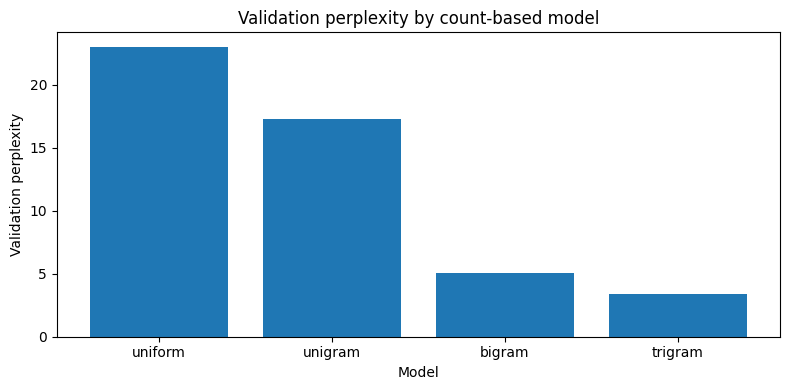

In [18]:
import matplotlib.pyplot as plt  # noqa: I001


model_names = [row.model_name for row in evaluation_rows]
validation_perplexities = [row.validation_perplexity for row in evaluation_rows]

plt.figure(figsize=(8, 4))
plt.bar(model_names, validation_perplexities)
plt.xlabel("Model")
plt.ylabel("Validation perplexity")
plt.title("Validation perplexity by count-based model")
plt.tight_layout()
plt.show()

## Plot Training and Validation Perplexity

The exponential scale can make train-to-validation gaps appear visually larger while preserving their underlying loss ordering.


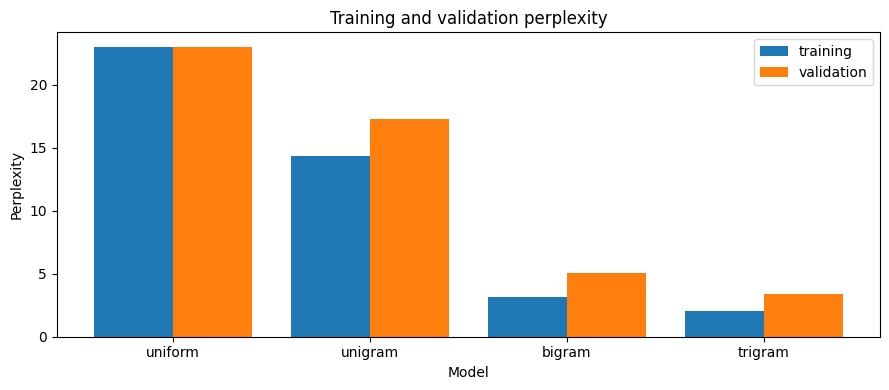

In [19]:
training_perplexities = [row.training_perplexity for row in evaluation_rows]
x_positions = list(range(len(model_names)))
bar_width = 0.4

plt.figure(figsize=(9, 4))
plt.bar(
    [position - bar_width / 2 for position in x_positions],
    training_perplexities,
    width=bar_width,
    label="training",
)
plt.bar(
    [position + bar_width / 2 for position in x_positions],
    validation_perplexities,
    width=bar_width,
    label="validation",
)
plt.xlabel("Model")
plt.ylabel("Perplexity")
plt.title("Training and validation perplexity")
plt.xticks(x_positions, model_names)
plt.legend()
plt.tight_layout()
plt.show()

## Rare Severe Errors Can Dominate

Because log loss penalizes tiny target probabilities strongly, several confident predictions do not necessarily compensate for one severe miss.


In [20]:
def perplexity_from_target_probabilities(probabilities: list[float]) -> float:
    if not probabilities:
        raise ValueError("probabilities cannot be empty.")
    average_loss = sum(
        negative_log_loss(probability) for probability in probabilities
    ) / len(probabilities)
    return perplexity_from_average_loss(average_loss)


case_a = [0.5, 0.5, 0.5, 0.5]
case_b = [0.9, 0.9, 0.9, 0.001]

print("Case A probabilities:", case_a)
print("Case A perplexity:", perplexity_from_target_probabilities(case_a))
print("Case B probabilities:", case_b)
print("Case B perplexity:", perplexity_from_target_probabilities(case_b))

Case A probabilities: [0.5, 0.5, 0.5, 0.5]
Case A perplexity: 2.0
Case B probabilities: [0.9, 0.9, 0.9, 0.001]
Case B perplexity: 6.085806194501845


Case B's one extremely low target probability raises its geometric-mean uncertainty despite three strong predictions.


## Average Before Exponentiating

Exponentiating total loss would make the reported number grow automatically with dataset length.

Per-token perplexity instead exponentiates average loss.


In [21]:
individual_losses = [0.4, 0.7, 1.1, 0.6]
total_loss = sum(individual_losses)
average_loss = total_loss / len(individual_losses)

print("Total loss:", total_loss)
print("Average loss:", average_loss)
print("Incorrect exp(total loss):", math.exp(total_loss))
print("Per-token perplexity exp(average loss):", math.exp(average_loss))

Total loss: 2.8
Average loss: 0.7
Incorrect exp(total loss): 16.444646771097048
Per-token perplexity exp(average loss): 2.0137527074704766


## Tokenization Defines the Unit

Perplexity is normalized per token, and tokenizers can create very different token sequences from the same text.


In [22]:
tiny_sentence = "the cat sat"
character_tokens = list(tiny_sentence)
word_tokens = tiny_sentence.split()

print("Text:", repr(tiny_sentence))
print("Character tokens:", character_tokens)
print("Character token count:", len(character_tokens))
print("Word tokens:", word_tokens)
print("Word token count:", len(word_tokens))

Text: 'the cat sat'
Character tokens: ['t', 'h', 'e', ' ', 'c', 'a', 't', ' ', 's', 'a', 't']
Character token count: 11
Word tokens: ['the', 'cat', 'sat']
Word token count: 3


A character-level perplexity measures uncertainty per character token, while a word-level perplexity measures uncertainty per word token.

Those are different prediction tasks with different sequence lengths and vocabulary sizes.


## Do Not Compare Raw Perplexity Across Tokenizers

Uniform perplexity itself equals vocabulary size, which can differ by orders of magnitude between character and word tokenization.


In [23]:
for example_vocabulary_size in [30, 1_000, 50_000]:
    uniform_loss = math.log(example_vocabulary_size)
    print(
        f"vocabulary {example_vocabulary_size:>6}: "
        f"uniform perplexity {perplexity_from_average_loss(uniform_loss):.1f}"
    )

vocabulary     30: uniform perplexity 30.0
vocabulary   1000: uniform perplexity 1000.0
vocabulary  50000: uniform perplexity 50000.0


Meaningful raw perplexity comparisons generally require the same tokenizer, evaluation text, context convention, and loss calculation.

Alternative normalized measures are needed when tokenization differs, and those require their own careful definitions.


## Perplexity Is Not Generated-Text Quality

Lower held-out perplexity means better average probability assignment to the evaluation tokens.

It does not directly measure factuality, usefulness, repetition, safety, semantic coherence, or the behavior of a particular decoding strategy.

Probability-based evaluation and qualitative generation inspection answer complementary questions.


## Complete Perplexity Pipeline

The final cell verifies finite results, the uniform-vocabulary identity, and matching loss and perplexity rankings.


In [24]:
final_rows = []

for model_name, model in models:
    validation_loss, validation_perplexity = evaluate_loss_and_perplexity(
        model,
        validation_token_ids,
        EVALUATION_CONTEXT_LENGTH,
    )
    assert math.isfinite(validation_loss)
    assert math.isfinite(validation_perplexity)
    final_rows.append((model_name, validation_loss, validation_perplexity))

assert abs(final_rows[0][2] - VOCABULARY_SIZE) < 1e-10
assert [name for name, loss, ppl in sorted(final_rows, key=lambda row: row[1])] == [
    name for name, loss, ppl in sorted(final_rows, key=lambda row: row[2])
]

print("Model    | Validation loss | Validation perplexity")
print("-" * 55)
for model_name, validation_loss, validation_perplexity in final_rows:
    print(
        f"{model_name:<8} | {validation_loss:>15.6f} | {validation_perplexity:>21.6f}"
    )

Model    | Validation loss | Validation perplexity
-------------------------------------------------------
uniform  |        3.135494 |             23.000000
unigram  |        2.849339 |             17.276357
bigram   |        1.616244 |              5.034148
trigram  |        1.230421 |              3.422669


## Common Mistakes

- Exponentiate average loss rather than total loss.

- Remember that lower loss and lower perplexity are both better.

- Use natural-log loss with `math.exp` so the functions are inverse scales.

- Expect exact uniform perplexity to equal vocabulary size.

- Compare raw perplexity only under the same tokenization and evaluation procedure.

- Do not interpret effective choices as a literal uniform prediction row.

- Keep perplexity distinct from every qualitative property of generated text.


## Takeaways

Perplexity is exactly the exponential of average natural-log loss.

Perplexity one corresponds to perfect target probability, and uniform guessing over $V$ tokens gives perplexity $V$.

Loss and perplexity rank models identically because exponentiation is monotonic.

The effective-choice interpretation makes the scale intuitive, but it does not imply literal uniform uncertainty at each step.

Raw perplexity comparisons require the same tokenizer, evaluation data, and evaluation procedure.

The next chapter introduces tensors as regular numerical containers for neural-language-model inputs, outputs, and parameters.
